In [88]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [89]:
data = np.load('../solutions/transient.npy')
dim = len(data)

In [90]:
time = np.zeros(dim)
flux = np.zeros(dim)
fluxerr = np.zeros(dim)
for i in range(dim):
    time[i], flux[i], fluxerr[i] = data[:][i]

<ErrorbarContainer object of 3 artists>

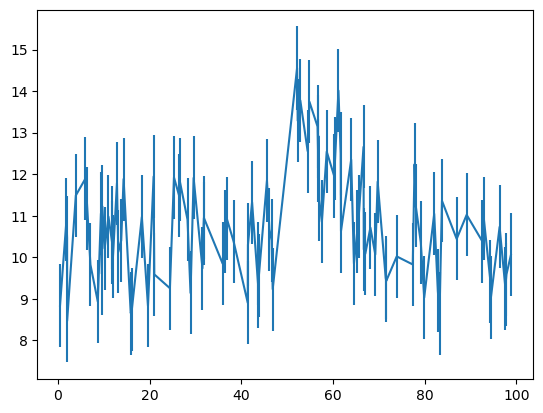

In [91]:
plt.errorbar(time, flux, fluxerr)

In [92]:
def likelihood(b, A, alpha, t0, t, f, errf):
    if t < t0:
        y = b
    else: 
        y = b + A*np.exp(-alpha*(t-t0))
    leastsq = np.mean(((y-f)/errf)**2)
    return leastsq

In [93]:
def prior_b(b):
    if b > 0. and b < 50.:
        return 1./50.
    else:
        return 0.
    
def prior_A(A):
    if A > 0. and A < 50.:
        return 1./50.
    else:
        return 0.
    
def prior_t0(t0):
    if t0 > 0. and t0 < 100.:
        return 1./100.
    else:
        return 0.
    
def prior_ln_alpha(loga):
    if loga > -5. and loga < 5.:
        return 1./10.
    else:
        return 0.

In [94]:
def logpost(params, t, f, errf):
    b, A, alpha, t0 = params
    post = likelihood(b, A, alpha, t0, t, f, errf) * prior_b(b) * prior_A(A) * prior_t0(t0) * prior_ln_alpha(np.log(alpha))
    return np.log(post)

In [95]:
ndim = 4  # number of parameters in the model
nwalkers = 10  # number of MCMC walkers
burn = 500  # "burn-in" period to let chains stabilize
nsteps = 10000

starting_guesses = np.random.random((nwalkers, ndim))

In [96]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, logpost, args=[time,flux, fluxerr])
sampler.run_mcmc(starting_guesses, nsteps)
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

emcee: Exception while calling your likelihood function:
  params: [0.10671241 0.0946585  0.03691303 0.8598071 ]
  args: [array([ 0.46954762,  1.87898004,  2.01075462,  2.02183974,  3.91877923,
        6.02254716,  6.41474963,  7.10360582,  8.71292997,  9.39405108,
        9.60984079,  9.71012758, 10.20448107, 11.03751412, 11.82744259,
       11.8727719 , 12.01965612, 12.89262977, 13.17978624, 13.81829513,
       14.33532874, 15.89695836, 16.13095179, 18.3191362 , 19.65823617,
       20.88767561, 21.03825611, 24.4425592 , 25.32916025, 26.45556121,
       26.53894909, 28.28069626, 28.94060929, 29.61401975, 31.54283509,
       31.79831794, 31.85689525, 35.95079006, 36.37107709, 36.87251707,
       38.34415188, 41.42629945, 41.466194  , 42.36547993, 43.70319538,
       43.75872113, 43.86015135, 45.61503322, 46.14793623, 46.63107729,
       46.86512016, 52.18483218, 52.32480535, 52.88949198, 54.4883183 ,
       54.88135039, 56.66014542, 56.80445611, 56.84339489, 57.01967704,
       57.5946

Traceback (most recent call last):
  File "/opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_51785/3531282255.py", line 3, in logpost
    post = likelihood(b, A, alpha, t0, t, f, errf) * prior_b(b) * prior_A(A) * prior_t0(t0) * prior_ln_alpha(np.log(alpha))
           ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_51785/192688287.py", line 2, in likelihood
    if t < t0:
       ^^^^^^
ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()